# Standalone notebook: HFA / High-gamma amplitude envelope (multiple methods)

This notebook is **standalone** (no package install required). It demonstrates:

1) Simple synthetic data generation with a **known ground-truth high-gamma amplitude envelope**
2) A **time–frequency plot** (a **spectrogram**, i.e., frequency vs time)
3) Multiple HFA computation methods:
   - **Method A:** IIR (SOS Butterworth) bandpass → Hilbert amplitude → smoothing
   - **Method B:** FIR (firwin) bandpass → Hilbert amplitude → smoothing
   - **Method C:** STFT power integrated over band → sqrt(power) → smoothing
4) Validation plots vs ground truth + error metrics

Typical HFA band: **70–150 Hz** (adjustable).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt, sosfilt, sosfilt_zi
from scipy.signal import firwin, filtfilt, hilbert, spectrogram, stft

np.set_printoptions(precision=4, suppress=True)


## 1) Synthetic signal with known high-gamma envelope

We simulate an **amplitude-modulated** high-gamma carrier:

- carrier: mixture of a few sinusoids in the band (e.g., 90/110/140 Hz)
- envelope: smooth burst(s) (sum of Gaussians)
- add noise + optional low-freq drift artifact

Ground-truth envelope is `env_true(t)`.


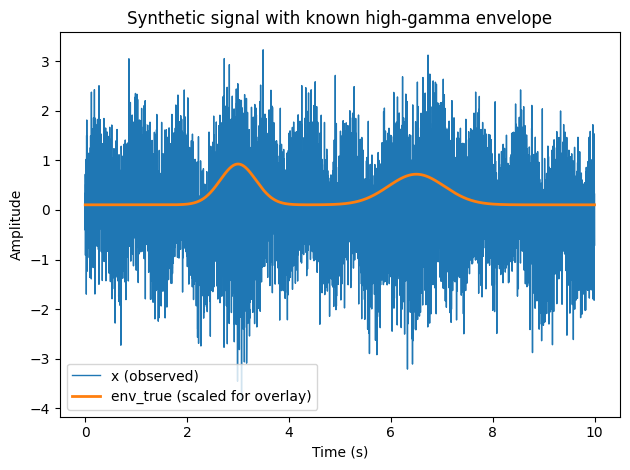

In [2]:
def gaussian(t, mu, sigma):
    return np.exp(-0.5 * ((t - mu) / sigma) ** 2)

def make_hfa_synth(fs=1000.0, dur_s=10.0, band=(70.0, 150.0), snr_db=-5.0,
                  add_drift=True, rng=None):
    """Return (t, x, env_true).
    env_true is a smooth nonnegative envelope (unit-ish scale).
    """
    if rng is None:
        rng = np.random.default_rng(0)
    fs = float(fs)
    N = int(round(dur_s * fs))
    t = np.arange(N) / fs

    # Envelope: sum of bursts + a small baseline
    env_true = (
        0.15
        + 1.2 * gaussian(t, 3.0, 0.35)
        + 0.9 * gaussian(t, 6.5, 0.55)
    )

    # Carrier: a few tones within high-gamma band with random phases
    tones = np.array([90.0, 110.0, 140.0])
    phases = rng.uniform(0, 2*np.pi, size=len(tones))
    carrier = np.zeros_like(t)
    for f, ph in zip(tones, phases):
        carrier += np.sin(2*np.pi*f*t + ph)
    carrier /= np.sqrt(len(tones))

    x_clean = env_true * carrier

    # Optional low-freq drift artifact
    if add_drift:
        drift = 0.4 * np.sin(2*np.pi*1.2*t) + 0.2 * np.sin(2*np.pi*0.3*t)
    else:
        drift = 0.0

    # Add white noise at desired SNR (power)
    sig_power = np.mean(x_clean**2)
    snr_lin = 10 ** (snr_db / 10)
    noise_power = sig_power / max(snr_lin, 1e-12)
    noise = rng.standard_normal(N) * np.sqrt(noise_power)

    x = x_clean + drift + noise
    return t, x, env_true


fs = 1000.0
band = (70.0, 150.0)
t, x, env_true = make_hfa_synth(fs=fs, dur_s=10.0, band=band, snr_db=-6.0, add_drift=True, rng=np.random.default_rng(1))

plt.figure()
plt.plot(t, x, label='x (observed)', linewidth=1)
plt.plot(t, env_true * np.std(x) * 0.8, label='env_true (scaled for overlay)', linewidth=2)
plt.title('Synthetic signal with known high-gamma envelope')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.show()


## 2) Time–frequency plot (Spectrogram)

The plot you’re thinking of is usually called a **spectrogram**: frequency vs time, colored by power.


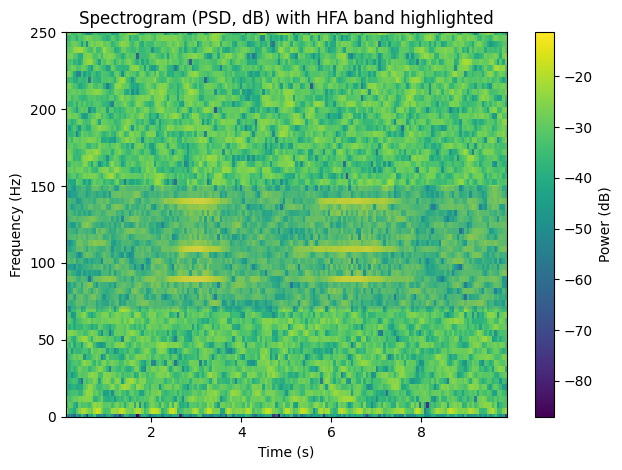

In [3]:
nperseg = 256
noverlap = 200
f, tt, Sxx = spectrogram(x, fs=fs, nperseg=nperseg, noverlap=noverlap, scaling='density', mode='psd')

plt.figure()
plt.pcolormesh(tt, f, 10*np.log10(Sxx + 1e-12))
plt.ylim(0, 250)
plt.axhspan(band[0], band[1], alpha=0.2)
plt.title('Spectrogram (PSD, dB) with HFA band highlighted')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Power (dB)')
plt.tight_layout()
plt.show()


## 3) Helper: smoothing (low-pass / moving average)

We’ll smooth the raw amplitude estimates because Hilbert amplitude can be jittery.


In [4]:
def smooth_moving_average(y, win_s, fs):
    """Simple moving average smoothing."""
    win = max(1, int(round(win_s * fs)))
    k = np.ones(win) / win
    return np.convolve(y, k, mode='same')

smooth_win_s = 0.05  # 50 ms


## 4) Method A — IIR (SOS Butterworth) bandpass → Hilbert amplitude

- Pros: efficient, short filter
- Cons: phase distortion if you do `sosfilt` (causal). Here we use `sosfiltfilt` for zero-phase (offline).

For **real-time**, you’d use `sosfilt` + keep `zi` state (and accept group delay / phase).


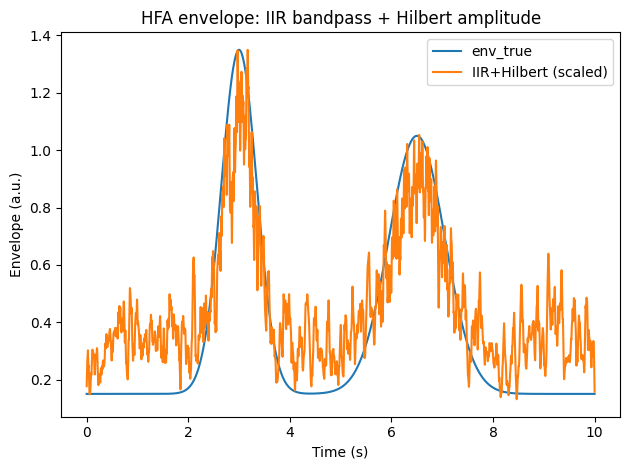

In [5]:
def hfa_iir_hilbert(x, fs, band, order=4, smooth_win_s=0.05):
    sos = butter(order, band, btype='bandpass', fs=fs, output='sos')
    x_bp = sosfiltfilt(sos, x)  # zero-phase (offline)
    amp = np.abs(hilbert(x_bp))
    amp_s = smooth_moving_average(amp, smooth_win_s, fs)
    return amp_s, x_bp


env_iir, x_iir_bp = hfa_iir_hilbert(x, fs, band, order=4, smooth_win_s=smooth_win_s)

plt.figure()
plt.plot(t, env_true, label='env_true')
plt.plot(t, env_iir / (np.max(env_iir) + 1e-12) * np.max(env_true), label='IIR+Hilbert (scaled)')
plt.title('HFA envelope: IIR bandpass + Hilbert amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Envelope (a.u.)')
plt.legend()
plt.tight_layout()
plt.show()


## 5) Method B — FIR bandpass → Hilbert amplitude

- Pros: linear-phase (nice for interpreting timing); stable
- Cons: longer filter (more compute) for sharp bands

Here we use `filtfilt` (zero-phase). For real-time you’d typically use overlap-save FFT FIR.


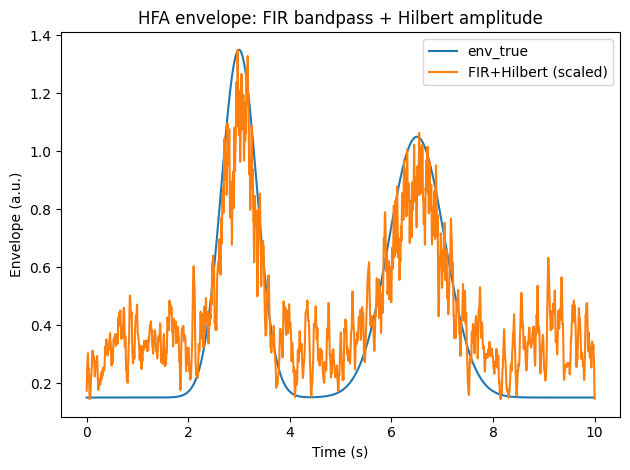

In [6]:
def hfa_fir_hilbert(x, fs, band, numtaps=401, smooth_win_s=0.05):
    b = firwin(numtaps=numtaps, cutoff=band, pass_zero=False, fs=fs)
    x_bp = filtfilt(b, [1.0], x)  # zero-phase (offline)
    amp = np.abs(hilbert(x_bp))
    amp_s = smooth_moving_average(amp, smooth_win_s, fs)
    return amp_s, x_bp


env_fir, x_fir_bp = hfa_fir_hilbert(x, fs, band, numtaps=401, smooth_win_s=smooth_win_s)

plt.figure()
plt.plot(t, env_true, label='env_true')
plt.plot(t, env_fir / (np.max(env_fir) + 1e-12) * np.max(env_true), label='FIR+Hilbert (scaled)')
plt.title('HFA envelope: FIR bandpass + Hilbert amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Envelope (a.u.)')
plt.legend()
plt.tight_layout()
plt.show()


## 6) Method C — STFT band power → sqrt(power)

Compute STFT, sum power in the HFA band, then take sqrt to get an amplitude-like measure.

- Pros: very interpretable; naturally gives time–frequency information
- Cons: windowing introduces time resolution tradeoffs; output is defined on STFT frame times


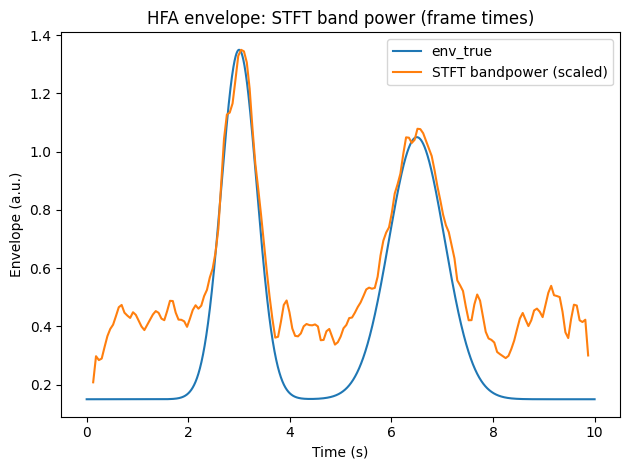

In [7]:
def hfa_stft_bandpower(x, fs, band, nperseg=256, noverlap=200, smooth_win_frames=3):
    f, tt, Z = stft(x, fs=fs, nperseg=nperseg, noverlap=noverlap, boundary=None)
    P = np.abs(Z) ** 2
    idx = (f >= band[0]) & (f <= band[1])
    bp = np.sum(P[idx, :], axis=0)  # power per time frame
    amp = np.sqrt(bp)

    # simple frame-domain smoothing
    k = np.ones(max(1, int(smooth_win_frames)))
    k = k / np.sum(k)
    amp_s = np.convolve(amp, k, mode='same')
    return tt, amp_s


tt_stft, env_stft = hfa_stft_bandpower(x, fs, band, nperseg=256, noverlap=200, smooth_win_frames=3)

plt.figure()
plt.plot(t, env_true, label='env_true')
plt.plot(tt_stft, env_stft / (np.max(env_stft) + 1e-12) * np.max(env_true), label='STFT bandpower (scaled)')
plt.title('HFA envelope: STFT band power (frame times)')
plt.xlabel('Time (s)')
plt.ylabel('Envelope (a.u.)')
plt.legend()
plt.tight_layout()
plt.show()


## 7) Validation: align scales + compute metrics

Envelopes are generally only identifiable **up to a scale factor** (depends on filter gain, carrier mix, etc.).

We do a simple least-squares scaling `a` to best match `env_true`:

`a = (env_true·env_est) / (env_est·env_est)`


In [8]:
def fit_scale(y_true, y_est):
    y_true = np.asarray(y_true)
    y_est = np.asarray(y_est)
    denom = float(np.dot(y_est, y_est))
    if denom <= 1e-20:
        return 0.0
    return float(np.dot(y_true, y_est) / denom)

def metrics(y_true, y_est):
    y_true = np.asarray(y_true)
    y_est = np.asarray(y_est)
    rmse = float(np.sqrt(np.mean((y_true - y_est) ** 2)))
    corr = float(np.corrcoef(y_true, y_est)[0, 1])
    return {'rmse': rmse, 'corr': corr}


# Scale-match IIR and FIR to env_true
a_iir = fit_scale(env_true, env_iir)
a_fir = fit_scale(env_true, env_fir)

env_iir_s = a_iir * env_iir
env_fir_s = a_fir * env_fir

# For STFT, compare at STFT frame times by sampling env_true
env_true_stft = np.interp(tt_stft, t, env_true)
a_stft = fit_scale(env_true_stft, env_stft)
env_stft_s = a_stft * env_stft

print('IIR  metrics:', metrics(env_true, env_iir_s))
print('FIR  metrics:', metrics(env_true, env_fir_s))
print('STFT metrics:', metrics(env_true_stft, env_stft_s))


IIR  metrics: {'rmse': 0.17568761605615354, 'corr': 0.9120038680169287}
FIR  metrics: {'rmse': 0.1731891757377212, 'corr': 0.914514210094977}
STFT metrics: {'rmse': 0.1614034130627824, 'corr': 0.975483895412204}


## 8) One overlay plot: ground truth vs all methods


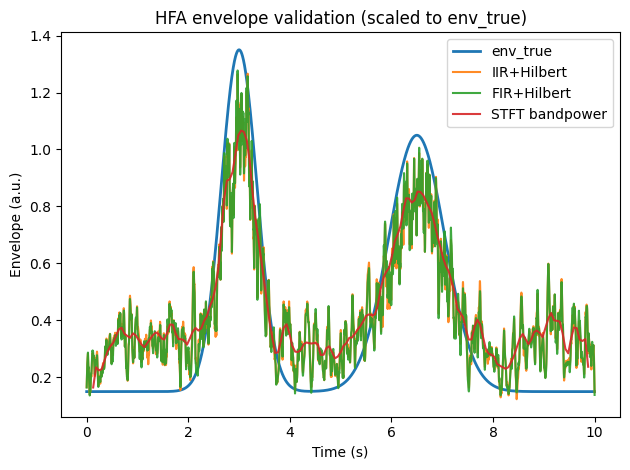

In [9]:
plt.figure()
plt.plot(t, env_true, label='env_true', linewidth=2)
plt.plot(t, env_iir_s, label='IIR+Hilbert', alpha=0.9)
plt.plot(t, env_fir_s, label='FIR+Hilbert', alpha=0.9)
plt.plot(tt_stft, env_stft_s, label='STFT bandpower', alpha=0.9)
plt.title('HFA envelope validation (scaled to env_true)')
plt.xlabel('Time (s)')
plt.ylabel('Envelope (a.u.)')
plt.legend()
plt.tight_layout()
plt.show()


## 9) Notes for real ECoG pipelines

- In practice, many groups do: bandpass → Hilbert amplitude → log / z-score → low-pass (e.g., 5–20 Hz).
- If you need **causal** (real-time), replace `filtfilt/sosfiltfilt` with `sosfilt` or FFT-FIR overlap-save.
- Watch out for **edge effects** (padding) and **filter transients**; chunking requires state handling.
- For multi-channel ECoG, run per-channel and optionally **common average reference** before HFA.
